In [ ]:
!pip install -q torch torchvision scikit-learn xgboost matplotlib seaborn pandas

# ===========================================================
# STEP 1: Imports and settings
# ===========================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, precision_recall_curve, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload CSV
csv_path = list(uploaded.keys())[0]

df = pd.read_csv(csv_path)
df = df.drop(columns=["Patient ID", "Timestamp"], errors='ignore')

# Encode categorical
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Features and target
target_col = "Risk Category"
X = df.drop(target_col, axis=1).values
y = df[target_col].values

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

Saving human_vital_signs_dataset_2024.csv to human_vital_signs_dataset_2024.csv


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

RANDOM_SEED = 42

# ---- Encode categorical columns ----
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# ---- Features and target ----
target_col = "Risk Category"
X = df.drop(target_col, axis=1).values
y = df[target_col].values

# ---- Standardize ----
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---- Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# ---- Print outputs for inspection ----
print("=== DataFrame after encoding ===")
display(df.head())

print("\n=== Feature matrix (X) shape ===")
print(X.shape)
print("First 5 rows of X:")
print(X[:5])

print("\n=== Target vector (y) shape ===")
print(y.shape)
print("First 10 target values:")
print(y[:10])

print("\n=== Training / Testing shapes ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

print("\n=== Target distribution ===")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")


=== DataFrame after encoding ===


,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,60,12,36.861707,95.702046,124,86,37,0,91.541618,1.679351,0.121033,38,32.459031,98.666667,0
1,63,18,36.511633,96.689413,126,84,77,1,50.704921,1.992546,0.117062,42,12.771246,98.000000,0
2,63,15,37.052049,98.508265,131,78,68,0,90.316760,1.770228,0.053200,53,28.821069,95.666667,1
3,99,16,36.654748,95.011801,118,72,41,0,96.006188,1.833629,0.064475,46,28.554611,87.333333,0
4,69,16,36.975098,98.623792,138,76,25,0,56.020006,1.866419,0.118484,62,16.081438,96.666667,0



=== Feature matrix (X) shape ===
(200020, 14)
First 5 rows of X:
[[-1.69081407 -1.5208114   0.26161327 -1.24936497 -0.05059201  1.12907957
  -0.79119033 -0.99893068  1.14329805 -0.48895311  0.72980261 -0.66683329
   1.15639194  0.87280088]
 [-1.43113822  1.09417539 -0.54633274 -0.56492611  0.18043693  0.78169051
   1.13311244  1.00107047 -1.67857892  1.67768532  0.59219924 -0.28239972
  -1.89733785  0.73385059]
 [-1.43113822 -0.21331801  0.70090758  0.69589373  0.75800929 -0.26047666
   0.70014432 -0.99893068  1.05865852  0.13971756 -1.62056403  0.77479259
   0.59211556  0.24752457]
 [ 1.68497195  0.22251312 -0.21603448 -1.72783913 -0.74367884 -1.30264384
  -0.59876006 -0.99893068  1.45180654  0.57831932 -1.22990223  0.10203384
   0.55078572 -1.48935407]
 [-0.91178653  0.22251312  0.52331017  0.77597651  1.56661059 -0.60786572
  -1.36848117 -0.99893068 -1.31129862  0.80515463  0.641494    1.63976811
  -1.38390111  0.45595001]]

=== Target vector (y) shape ===
(200020,)
First 10 target

In [ ]:
class VitalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_clients(X, y, num_clients=3):
    clients = []
    size = len(X)//num_clients
    for i in range(num_clients):
        start, end = i*size, (i+1)*size
        dataset = VitalDataset(X[start:end], y[start:end])
        loader = DataLoader(dataset, batch_size=32, shuffle=True)
        clients.append({"loader": loader, "size": len(dataset)})
    return clients

clients = create_clients(X_train, y_train)
print(f"{len(clients)} clients created.")

3 clients created.


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=None):
        super().__init__()
        if output_dim is None:
            output_dim = len(np.unique(y_train))
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU()
        )
        self.classifier = nn.Linear(128, output_dim)
    def forward(self, x):
        x = self.feature(x)
        return self.classifier(x)

def local_train(model, loader, device, epochs=3):
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model.state_dict()

In [ ]:
def init_server_states(model):
    m, v = {}, {}
    for k, p in model.state_dict().items():
        m[k] = torch.zeros_like(p)
        v[k] = torch.zeros_like(p)
    return m, v

def fedadam(global_model, client_weights, client_sizes, m, v, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    global_params = global_model.state_dict()
    total = sum(client_sizes)
    for k in global_params:
        delta = sum((client_sizes[i]/total)*(client_weights[i][k]-global_params[k])
                    for i in range(len(client_weights)))
        m[k] = beta1*m[k] + (1-beta1)*delta
        v[k] = beta2*v[k] + (1-beta2)*(delta**2)
        global_params[k] += lr*m[k]/(torch.sqrt(v[k])+eps)
    global_model.load_state_dict(global_params)
    return global_model, m, v

In [ ]:
input_dim = X_train.shape[1]
global_model = MLP(input_dim).to(device)
m, v = init_server_states(global_model)
ROUNDS = 10

for r in range(ROUNDS):
    client_weights, client_sizes = [], []
    for client in clients:
        local_model = MLP(input_dim).to(device)
        local_model.load_state_dict(global_model.state_dict())
        w = local_train(local_model, client["loader"], device, epochs=3)
        client_weights.append(w)
        client_sizes.append(client["size"])
    global_model, m, v = fedadam(global_model, client_weights, client_sizes, m, v)
    print(f"Round {r+1}/{ROUNDS} completed")


Round 1/10 completed
Round 2/10 completed
Round 3/10 completed
Round 4/10 completed
Round 5/10 completed
Round 6/10 completed
Round 7/10 completed
Round 8/10 completed
Round 9/10 completed
Round 10/10 completed


In [ ]:
# Train XGBoost on same data
xgb_model = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
xgb_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:45:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
def evaluate_model(model, X_test, y_test, is_torch=False):
    if is_torch:
        model.eval()
        with torch.no_grad():
            X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
            y_pred = model(X_t).argmax(dim=1).cpu().numpy()
            probs = torch.softmax(model(X_t), dim=1).cpu().numpy()
    else:
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)
        else:
            probs = y_pred
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    auc_val = auc(*roc_curve(y_test, probs[:,1])[:2]) if probs.shape[1]==2 else np.nan
    cm = confusion_matrix(y_test, y_pred)
    return acc, prec, rec, f1, auc_val, cm, probs

# Evaluate all models
mlp_metrics = evaluate_model(global_model, X_test, y_test, is_torch=True)
xgb_metrics = evaluate_model(xgb_model, X_test, y_test)
rf_metrics = evaluate_model(rf_model, X_test, y_test)

# MXBoost ensemble (majority vote)
with torch.no_grad(): # Added this context manager to disable gradient calculation
    mlp_probs = torch.softmax(global_model(torch.tensor(X_test, dtype=torch.float32).to(device)), dim=1).cpu().numpy()
xgb_probs = xgb_model.predict_proba(X_test)
mxboost_probs = (mlp_probs + xgb_probs)/2
mxboost_pred = mxboost_probs.argmax(axis=1)
mxboost_acc = accuracy_score(y_test, mxboost_pred)
mxboost_prec = precision_score(y_test, mxboost_pred, average='macro')
mxboost_rec = recall_score(y_test, mxboost_pred, average='macro')
mxboost_f1 = f1_score(y_test, mxboost_pred, average='macro')
mxboost_auc = auc(*roc_curve(y_test, mxboost_probs[:,1])[:2])
mxboost_cm = confusion_matrix(y_test, mxboost_pred)

In [ ]:
import pandas as pd
summary = pd.DataFrame({
    "Model": ["MLP", "XGBoost", "MXBoost", "Random Forest"],
    "Accuracy":[mlp_metrics[0], xgb_metrics[0], mxboost_acc, rf_metrics[0]],
    "Precision":[mlp_metrics[1], xgb_metrics[1], mxboost_prec, rf_metrics[1]],
    "Recall":[mlp_metrics[2], xgb_metrics[2], mxboost_rec, rf_metrics[2]],
    "F1-Score":[mlp_metrics[3], xgb_metrics[3], mxboost_f1, rf_metrics[3]],
    "AUC":[mlp_metrics[4], xgb_metrics[4], mxboost_auc, rf_metrics[4]]
})
print(summary)

           Model  Accuracy  Precision    Recall  F1-Score       AUC
0            MLP  0.971828   0.974537  0.970320  0.971651  0.999787
1        XGBoost  0.997350   0.997356  0.997331  0.997343  0.999985
2        MXBoost  0.997200   0.997317  0.997078  0.997192  0.999971
3  Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000


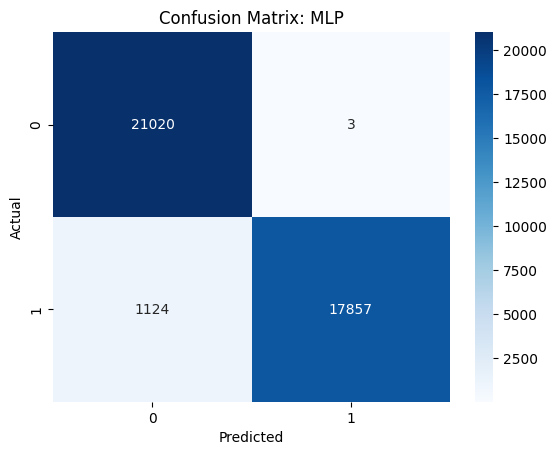

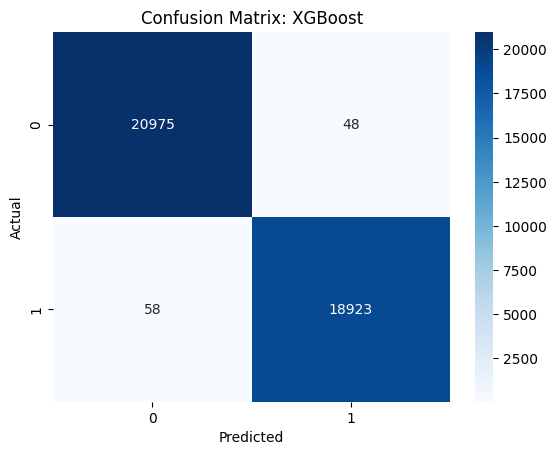

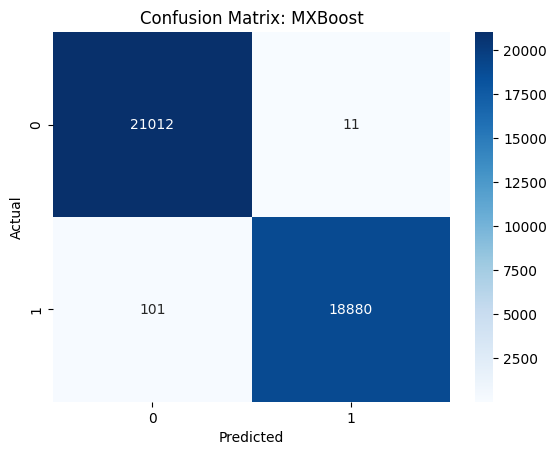

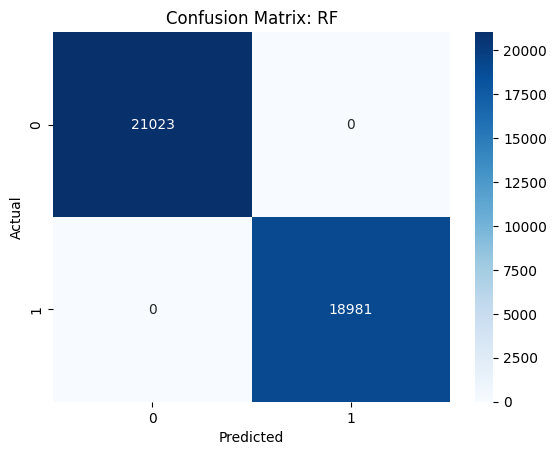

In [ ]:
models_cm = {"MLP":mlp_metrics[5], "XGBoost":xgb_metrics[5], "MXBoost":mxboost_cm, "RF":rf_metrics[5]}
for name, cm in models_cm.items():
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


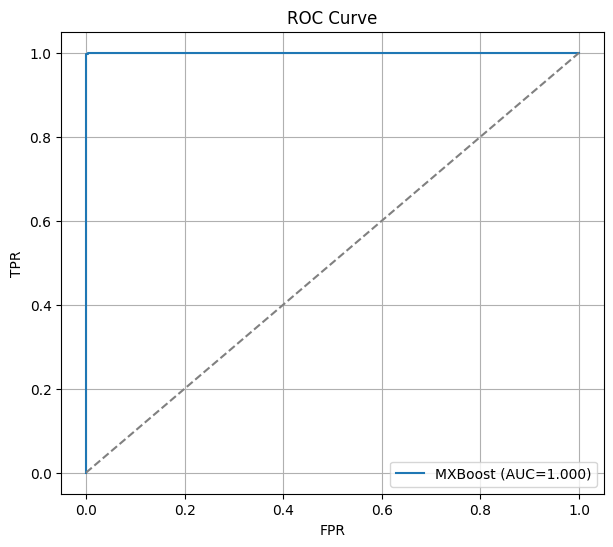

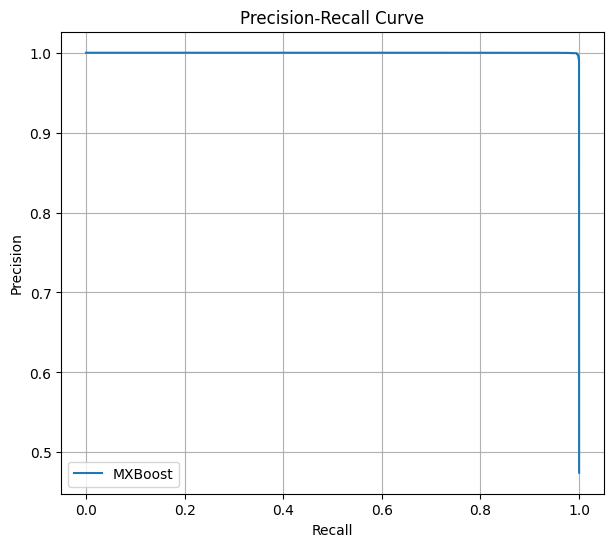

In [ ]:
plt.figure(figsize=(7,6))
fpr, tpr, _ = roc_curve(y_test, mxboost_probs[:,1])
plt.plot(fpr, tpr, label=f"MXBoost (AUC={mxboost_auc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(7,6))
prec_curve, rec_curve, _ = precision_recall_curve(y_test, mxboost_probs[:,1])
plt.plot(rec_curve, prec_curve, label=f"MXBoost")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
plt.legend(); plt.grid(True); plt.show()

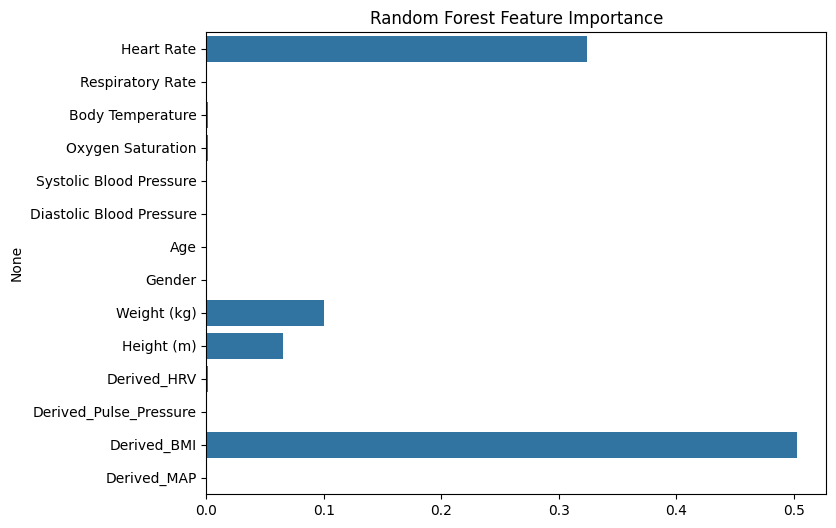

In [ ]:
feat_importances = rf_model.feature_importances_
plt.figure(figsize=(8,6))
sns.barplot(x=feat_importances, y=df.drop(target_col, axis=1).columns)
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
patient_X = X_test[0:1]
patient_y = y_test[0:1]

# Simulate 5 time steps
for t in range(5):
    X_torch = torch.tensor(patient_X, dtype=torch.float32).to(device)
    with torch.no_grad(): # Disable gradient calculation for inference
        output = global_model(X_torch)
        prob = torch.softmax(output, dim=1).cpu().numpy()[0]
    status = "Alert (Abnormal)" if prob[1] > 0.5 else "Normal"
    print(f"Time {t+1}: Probability {prob[1]:.2f} -> {status}")

Time 1: Probability 1.00 -> Alert (Abnormal)
Time 2: Probability 1.00 -> Alert (Abnormal)
Time 3: Probability 1.00 -> Alert (Abnormal)
Time 4: Probability 1.00 -> Alert (Abnormal)
Time 5: Probability 1.00 -> Alert (Abnormal)


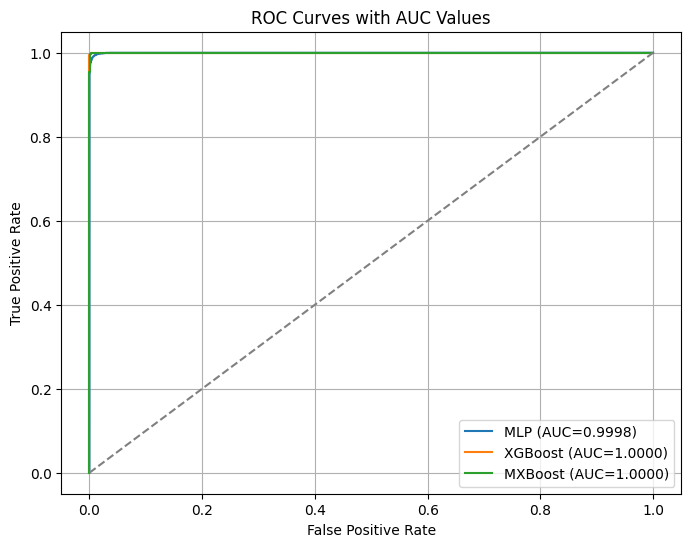

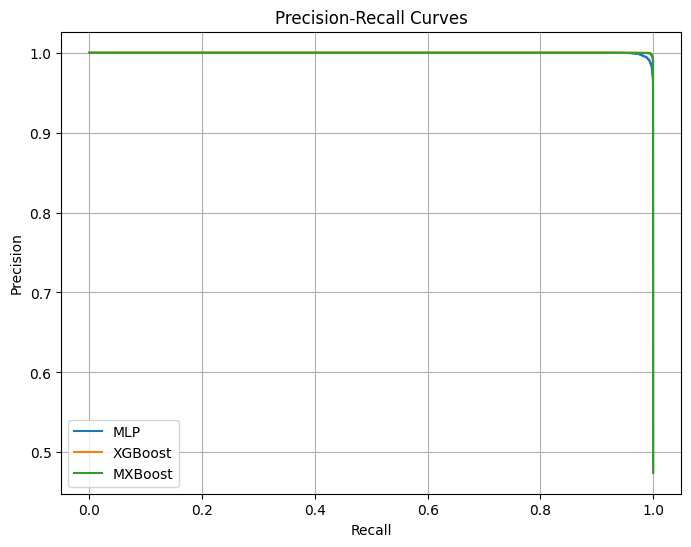

In [ ]:
# ===========================================================
# ROC and Precision-Recall Curves with AUC values shown
# ===========================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve

models = {
    "MLP": (mlp_metrics[6], mlp_metrics[4], True),  # probs, auc, is_torch
    "XGBoost": (xgb_metrics[6], xgb_metrics[4], False),
    "MXBoost": (mxboost_probs, mxboost_auc, False)
}

# ROC Curves
plt.figure(figsize=(8,6))
for name, (probs, auc_val, is_torch) in models.items():
    if probs.shape[1]==2:
        fpr, tpr, _ = roc_curve(y_test, probs[:,1])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with AUC Values")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curves
plt.figure(figsize=(8,6))
for name, (probs, auc_val, is_torch) in models.items():
    if probs.shape[1]==2:
        precision, recall, _ = precision_recall_curve(y_test, probs[:,1])
        plt.plot(recall, precision, label=f"{name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()
